<!-- Feature Engineered some of the important features -->

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.linear_model import LinearRegression
# from xgboost import XGBRegressor
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import joblib

# # Set style
# sns.set_style('whitegrid')
# plt.rcParams['figure.figsize'] = (14, 6)


In [ ]:
# print("="*60)
# print("LOADING FULL FINANCIAL DATASET")
# print("="*60)

# # Load all 47 features
# df_full = pd.read_csv('data/raw/financial_regression.csv')

# print(f"\nFull dataset shape: {df_full.shape}")
# print(f"Total columns: {len(df_full.columns)}")

# # Show all column categories
# print("\nColumns by category:")
# print(f"  Gold: {[col for col in df_full.columns if 'gold' in col.lower()]}")
# print(f"  Silver: {[col for col in df_full.columns if 'silver' in col.lower()]}")
# print(f"  Oil: {[col for col in df_full.columns if 'oil' in col.lower()]}")
# print(f"  S&P500: {[col for col in df_full.columns if 'sp500' in col.lower()]}")
# print(f"  Economic: ['us_rates_%', 'CPI', 'GDP', 'eur_usd', 'usd_chf']")

LOADING FULL FINANCIAL DATASET

Full dataset shape: (3904, 47)
Total columns: 47

Columns by category:
  Gold: ['gold open', 'gold high', 'gold low', 'gold close', 'gold volume']
  Silver: ['silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low']
  Oil: ['oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low']
  S&P500: ['sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low']
  Economic: ['us_rates_%', 'CPI', 'GDP', 'eur_usd', 'usd_chf']


In [ ]:
# # Convert date
# df_full['date'] = pd.to_datetime(df_full['date'])
# df_full = df_full.sort_values('date').reset_index(drop=True)

# print(f"\nDate range: {df_full['date'].min()} to {df_full['date'].max()}")
# print(f"Total rows: {len(df_full):,}")


Date range: 2010-01-14 00:00:00 to 2024-10-23 00:00:00
Total rows: 3,904


In [ ]:
# print("\n" + "="*60)
# print("SELECTING ESSENTIAL FEATURES")
# print("="*60)

# # Define essential columns we want to keep
# essential_columns = [
#     'date',
#     # Gold (our target)
#     'gold open', 'gold high', 'gold low', 'gold close', 'gold volume',
#     # Silver (highly correlated)
#     'silver close', 'silver volume',
#     # Stock market (risk sentiment)
#     'sp500 close', 'sp500 volume',
#     # Currency (gold priced in USD)
#     'eur_usd',
#     # Oil (inflation indicator)
#     'oil close'
# ]

# # Create essential dataset
# df_essential = df_full[essential_columns].copy()

# print(f"\nSelected {len(essential_columns)} essential columns:")
# for col in essential_columns:
#     print(f"  - {col}")

# print(f"\nDataset shape: {df_essential.shape}")


SELECTING ESSENTIAL FEATURES

Selected 12 essential columns:
  - date
  - gold open
  - gold high
  - gold low
  - gold close
  - gold volume
  - silver close
  - silver volume
  - sp500 close
  - sp500 volume
  - eur_usd
  - oil close

Dataset shape: (3904, 12)


In [ ]:
# print("\n" + "="*60)
# print("WHY THESE FEATURES?")
# print("="*60)

# explanations = {
#     'silver close': 'Precious metal twin - moves with gold 85% of time',
#     'sp500 close': 'Risk indicator - inverse relationship with gold',
#     'eur_usd': 'Dollar strength - gold priced in USD',
#     'oil close': 'Inflation proxy - affects gold demand'
# }

# for feature, reason in explanations.items():
#     print(f"\n{feature}:")
#     print(f"  → {reason}")


WHY THESE FEATURES?

silver close:
  → Precious metal twin - moves with gold 85% of time

sp500 close:
  → Risk indicator - inverse relationship with gold

eur_usd:
  → Dollar strength - gold priced in USD

oil close:
  → Inflation proxy - affects gold demand


In [ ]:
# print("\n" + "="*60)
# print("CHECKING DATA QUALITY")
# print("="*60)

# # Check missing values
# missing = df_essential.isnull().sum()
# missing_pct = (missing / len(df_essential)) * 100

# print("\nMissing values:")
# for col in df_essential.columns:
#     if missing[col] > 0:
#         print(f"  {col}: {missing[col]} ({missing_pct[col]:.1f}%)")

# if missing.sum() == 0:
#     print("  ✓ No missing values!")


CHECKING DATA QUALITY

Missing values:
  gold open: 185 (4.7%)
  gold high: 185 (4.7%)
  gold low: 185 (4.7%)
  gold close: 185 (4.7%)
  gold volume: 185 (4.7%)
  silver close: 185 (4.7%)
  silver volume: 185 (4.7%)
  sp500 close: 185 (4.7%)
  sp500 volume: 185 (4.7%)
  eur_usd: 210 (5.4%)
  oil close: 185 (4.7%)


In [ ]:
if df_essential.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    
    # Forward fill
    df_essential = df_essential.ffill()
    
    # Backward fill any remaining (at the start)
    df_essential = df_essential.bfill()
    
    # Check again
    remaining_missing = df_essential.isnull().sum().sum()
    print(f"✓ Missing values after filling: {remaining_missing}")
else:
    print("✓ No missing values to handle")


Handling missing values...
✓ Missing values after filling: 0


In [ ]:
# # Validate gold OHLC
# print("\nValidating gold price data...")

# invalid = df_essential[
#     (df_essential['gold high'] < df_essential['gold low']) |
#     (df_essential['gold high'] < df_essential['gold close']) |
#     (df_essential['gold low'] > df_essential['gold close'])
# ]

# if len(invalid) > 0:
#     print(f"⚠ Found {len(invalid)} invalid rows - removing...")
#     df_essential = df_essential[
#         (df_essential['gold high'] >= df_essential['gold low']) &
#         (df_essential['gold high'] >= df_essential['gold close']) &
#         (df_essential['gold low'] <= df_essential['gold close'])
#     ].reset_index(drop=True)
# else:
#     print("✓ All gold price data valid")

# print(f"\nFinal dataset: {len(df_essential):,} rows")


Validating gold price data...
✓ All gold price data valid

Final dataset: 3,904 rows


<!-- Columns renamed for clarity -->

In [ ]:
# print("\n" + "="*60)
# print("FEATURE ENGINEERING WITH ECONOMIC DATA")
# print("="*60)

# # Rename for easier access
# df_features = df_essential.copy()
# df_features.columns = [
#     'Date', 
#     'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
#     'Silver_Close', 'Silver_Volume',
#     'SP500_Close', 'SP500_Volume',
#     'EUR_USD',
#     'Oil_Close'
# ]

# print("✓ Columns renamed for clarity")


FEATURE ENGINEERING WITH ECONOMIC DATA
✓ Columns renamed for clarity


In [ ]:
# print("\n1. Creating gold technical indicators...")

# # Moving averages
# df_features['Gold_SMA_20'] = df_features['Gold_Close'].rolling(window=20).mean()
# df_features['Gold_SMA_50'] = df_features['Gold_Close'].rolling(window=50).mean()
# df_features['Gold_EMA_20'] = df_features['Gold_Close'].ewm(span=20, adjust=False).mean()

# # RSI
# def calculate_rsi(data, window=14):
#     delta = data.diff()
#     gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
#     loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
#     rs = gain / loss
#     rsi = 100 - (100 / (1 + rs))
#     return rsi

# df_features['Gold_RSI_14'] = calculate_rsi(df_features['Gold_Close'], 14)

# # MACD
# exp1 = df_features['Gold_Close'].ewm(span=12, adjust=False).mean()
# exp2 = df_features['Gold_Close'].ewm(span=26, adjust=False).mean()
# df_features['Gold_MACD'] = exp1 - exp2
# df_features['Gold_MACD_Signal'] = df_features['Gold_MACD'].ewm(span=9, adjust=False).mean()

# # Price changes
# df_features['Gold_Returns'] = df_features['Gold_Close'].pct_change() * 100
# df_features['Gold_Volatility'] = df_features['Gold_Returns'].rolling(window=20).std()

# # Lag features
# for lag in [1, 2, 3, 5, 7]:
#     df_features[f'Gold_Lag_{lag}'] = df_features['Gold_Close'].shift(lag)

# print("  ✓ Gold technical indicators created")


1. Creating gold technical indicators...
  ✓ Gold technical indicators created


In [ ]:
# print("\n2. Creating silver features...")

# # Silver technical indicators
# df_features['Silver_SMA_20'] = df_features['Silver_Close'].rolling(window=20).mean()
# df_features['Silver_Returns'] = df_features['Silver_Close'].pct_change() * 100

# # Lag features
# for lag in [1, 2, 3]:
#     df_features[f'Silver_Lag_{lag}'] = df_features['Silver_Close'].shift(lag)

# print("  ✓ Silver features created")


2. Creating silver features...
  ✓ Silver features created


In [ ]:
# print("\n3. Creating cross-asset relationship features...")

# # Gold/Silver ratio (classic trading indicator)
# df_features['Gold_Silver_Ratio'] = df_features['Gold_Close'] / df_features['Silver_Close']
# df_features['Gold_Silver_Ratio_SMA'] = df_features['Gold_Silver_Ratio'].rolling(window=20).mean()

# # Gold vs S&P500 relationship (risk-on vs risk-off)
# df_features['Gold_SP500_Ratio'] = df_features['Gold_Close'] / df_features['SP500_Close']

# # Correlation features (30-day rolling)
# df_features['Gold_Silver_Corr'] = df_features['Gold_Returns'].rolling(window=30).corr(
#     df_features['Silver_Returns']
# )

# print("  ✓ Cross-asset features created")


3. Creating cross-asset relationship features...
  ✓ Cross-asset features created


In [ ]:
# print("\n4. Creating S&P500 features...")

# # S&P500 returns and volatility
# df_features['SP500_Returns'] = df_features['SP500_Close'].pct_change() * 100
# df_features['SP500_Volatility'] = df_features['SP500_Returns'].rolling(window=20).std()

# # S&P500 trend
# df_features['SP500_SMA_50'] = df_features['SP500_Close'].rolling(window=50).mean()
# df_features['SP500_Trend'] = (df_features['SP500_Close'] > df_features['SP500_SMA_50']).astype(int)

# # Lag features
# for lag in [1, 2, 3]:
#     df_features[f'SP500_Lag_{lag}'] = df_features['SP500_Close'].shift(lag)

# print("  ✓ S&P500 features created")


4. Creating S&P500 features...
  ✓ S&P500 features created


In [ ]:
# print("\n5. Creating currency features...")

# # EUR/USD changes
# df_features['EUR_USD_Change'] = df_features['EUR_USD'].pct_change() * 100
# df_features['EUR_USD_SMA_20'] = df_features['EUR_USD'].rolling(window=20).mean()

# # Currency strength indicator (higher EUR/USD = weaker USD)
# df_features['USD_Strength'] = -df_features['EUR_USD_Change']  # Inverse

# # Lag features
# for lag in [1, 2, 3]:
#     df_features[f'EUR_USD_Lag_{lag}'] = df_features['EUR_USD'].shift(lag)

# print("  ✓ Currency features created")


5. Creating currency features...
  ✓ Currency features created


In [ ]:
# print("\n6. Creating oil features...")

# # Oil returns
# df_features['Oil_Returns'] = df_features['Oil_Close'].pct_change() * 100
# df_features['Oil_SMA_20'] = df_features['Oil_Close'].rolling(window=20).mean()

# # Oil volatility (high oil volatility = inflation uncertainty)
# df_features['Oil_Volatility'] = df_features['Oil_Returns'].rolling(window=20).std()

# # Lag features
# for lag in [1, 2, 3]:
#     df_features[f'Oil_Lag_{lag}'] = df_features['Oil_Close'].shift(lag)

# print("  ✓ Oil features created")


6. Creating oil features...
  ✓ Oil features created


In [ ]:
# print("\n7. Creating market regime indicators...")

# # Risk-on vs Risk-off indicator
# # When S&P up and Gold down = Risk-on
# # When S&P down and Gold up = Risk-off
# df_features['Risk_On_Indicator'] = (
#     (df_features['SP500_Returns'] > 0).astype(int) - 
#     (df_features['Gold_Returns'] > 0).astype(int)
# )

# # Volatility regime (high volatility = uncertain times = good for gold)
# df_features['High_Volatility'] = (
#     df_features['Gold_Volatility'] > df_features['Gold_Volatility'].rolling(window=60).mean()
# ).astype(int)

# print("  ✓ Market regime indicators created")


7. Creating market regime indicators...
  ✓ Market regime indicators created


In [ ]:
# print("\n8. Creating time features...")

# # Extract date components
# df_features['Year'] = df_features['Date'].dt.year
# df_features['Month'] = df_features['Date'].dt.month
# df_features['Quarter'] = df_features['Date'].dt.quarter
# df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek

# # Cyclical encoding
# df_features['Month_Sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
# df_features['Month_Cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)

# print("  ✓ Time features created")


8. Creating time features...
  ✓ Time features created


In [ ]:
# print("\n" + "="*60)
# print("FEATURE ENGINEERING SUMMARY")
# print("="*60)

# print(f"\nOriginal columns: {len(essential_columns)}")
# print(f"Total columns now: {len(df_features.columns)}")
# print(f"New features created: {len(df_features.columns) - len(essential_columns)}")

# print(f"\nFeature categories:")
# print(f"  Gold features: {len([c for c in df_features.columns if 'Gold' in c])}")
# print(f"  Silver features: {len([c for c in df_features.columns if 'Silver' in c])}")
# print(f"  S&P500 features: {len([c for c in df_features.columns if 'SP500' in c])}")
# print(f"  Currency features: {len([c for c in df_features.columns if 'EUR_USD' in c or 'USD' in c])}")
# print(f"  Oil features: {len([c for c in df_features.columns if 'Oil' in c])}")
# print(f"  Cross-asset features: {len([c for c in df_features.columns if 'Ratio' in c or 'Corr' in c])}")
# print(f"  Time features: {len([c for c in df_features.columns if any(x in c for x in ['Year', 'Month', 'Quarter', 'Day'])])}")


FEATURE ENGINEERING SUMMARY

Original columns: 12
Total columns now: 61
New features created: 49

Feature categories:
  Gold features: 22
  Silver features: 10
  S&P500 features: 10
  Currency features: 7
  Oil features: 7
  Cross-asset features: 4
  Time features: 6


In [ ]:
# print("\n" + "="*60)
# print("CLEANING FEATURES")
# print("="*60)

# # Check NaN
# print(f"Rows before removing NaN: {len(df_features):,}")
# nan_count = df_features.isnull().sum().sum()
# print(f"Total NaN values: {nan_count:,}")

# # Remove NaN (from rolling windows and lags)
# df_features_clean = df_features.dropna().reset_index(drop=True)

# print(f"Rows after removing NaN: {len(df_features_clean):,}")
# print(f"Rows removed: {len(df_features) - len(df_features_clean):,}")


CLEANING FEATURES
Rows before removing NaN: 3,904
Total NaN values: 344
Rows after removing NaN: 3,855
Rows removed: 49


In [ ]:
# print("\n" + "="*60)
# print("PREPARING FOR MACHINE LEARNING")
# print("="*60)

# # Columns to exclude from features
# exclude_cols = [
#     'Date',
#     'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',  # Same-day data
#     'Silver_Close', 'Silver_Volume',  # Using lag features instead
#     'SP500_Close', 'SP500_Volume',    # Using lag features instead
#     'EUR_USD',                         # Using lag features instead
#     'Oil_Close'                        # Using lag features instead
# ]

# # Get feature columns
# feature_cols = [col for col in df_features_clean.columns if col not in exclude_cols]

# # Create X and y
# X_enhanced = df_features_clean[feature_cols]
# y_enhanced = df_features_clean['Gold_Close']

# print(f"\nFeatures (X): {X_enhanced.shape}")
# print(f"Target (y): {y_enhanced.shape}")

# print(f"\nTotal features: {len(feature_cols)}")
# print(f"\nSample features:")
# for i, col in enumerate(feature_cols[:15], 1):
#     print(f"  {i}. {col}")
# print(f"  ... and {len(feature_cols) - 15} more")


PREPARING FOR MACHINE LEARNING

Features (X): (3855, 49)
Target (y): (3855,)

Total features: 49

Sample features:
  1. Gold_SMA_20
  2. Gold_SMA_50
  3. Gold_EMA_20
  4. Gold_RSI_14
  5. Gold_MACD
  6. Gold_MACD_Signal
  7. Gold_Returns
  8. Gold_Volatility
  9. Gold_Lag_1
  10. Gold_Lag_2
  11. Gold_Lag_3
  12. Gold_Lag_5
  13. Gold_Lag_7
  14. Silver_SMA_20
  15. Silver_Returns
  ... and 34 more


In [ ]:
# # Same chronological split as baseline (80/20)
# split_idx = int(len(X_enhanced) * 0.8)

# X_train_enh = X_enhanced[:split_idx]
# X_test_enh = X_enhanced[split_idx:]
# y_train_enh = y_enhanced[:split_idx]
# y_test_enh = y_enhanced[split_idx:]

# dates_train_enh = df_features_clean['Date'][:split_idx]
# dates_test_enh = df_features_clean['Date'][split_idx:]

# print("\n" + "="*60)
# print("TRAIN-TEST SPLIT")
# print("="*60)

# print(f"\nTraining set:")
# print(f"  Rows: {len(X_train_enh):,}")
# print(f"  Date range: {dates_train_enh.min()} to {dates_train_enh.max()}")

# print(f"\nTest set:")
# print(f"  Rows: {len(X_test_enh):,}")
# print(f"  Date range: {dates_test_enh.min()} to {dates_test_enh.max()}")


TRAIN-TEST SPLIT

Training set:
  Rows: 3,084
  Date range: 2010-03-24 00:00:00 to 2021-11-22 00:00:00

Test set:
  Rows: 771
  Date range: 2021-11-23 00:00:00 to 2024-10-23 00:00:00


In [ ]:
# # Save for later use
# df_features_clean.to_csv('data/processed/gold_enhanced_features.csv', index=False)
# print("\n✓ Saved enhanced feature data")


✓ Saved enhanced feature data


In [ ]:
# print("\n" + "="*80)
# print("MODEL 1: LINEAR REGRESSION (ENHANCED)")
# print("="*80)

# lr_enh = LinearRegression()

# print("\nTraining...")
# lr_enh.fit(X_train_enh, y_train_enh)
# print("✓ Training complete")

# # Predictions
# y_pred_lr_enh_test = lr_enh.predict(X_test_enh)

# # Evaluate
# test_rmse_lr_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_lr_enh_test))
# test_mae_lr_enh = mean_absolute_error(y_test_enh, y_pred_lr_enh_test)
# test_r2_lr_enh = r2_score(y_test_enh, y_pred_lr_enh_test)
# test_mape_lr_enh = np.mean(np.abs((y_test_enh - y_pred_lr_enh_test) / y_test_enh)) * 100

# print("\n🎯 TEST Set Performance:")
# print(f"  RMSE: ${test_rmse_lr_enh:.2f}")
# print(f"  MAE:  ${test_mae_lr_enh:.2f}")
# print(f"  R²:   {test_r2_lr_enh:.4f}")
# print(f"  MAPE: {test_mape_lr_enh:.2f}%")

# # Save
# joblib.dump(lr_enh, 'models/saved_models/enhanced_linear_regression.pkl')
# print("\n✓ Model saved")


MODEL 1: LINEAR REGRESSION (ENHANCED)

Training...
✓ Training complete

🎯 TEST Set Performance:
  RMSE: $0.33
  MAE:  $0.24
  R²:   0.9998
  MAPE: 0.13%

✓ Model saved


In [ ]:
# print("\n" + "="*80)
# print("MODEL 2: RANDOM FOREST (ENHANCED)")
# print("="*80)

# rf_enh = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     random_state=42,
#     n_jobs=-1
# )

# print("\nTraining Random Forest...")
# print("(This might take 30-60 seconds...)")
# rf_enh.fit(X_train_enh, y_train_enh)
# print("✓ Training complete")

# # Predictions
# y_pred_rf_enh_test = rf_enh.predict(X_test_enh)

# # Evaluate
# test_rmse_rf_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_rf_enh_test))
# test_mae_rf_enh = mean_absolute_error(y_test_enh, y_pred_rf_enh_test)
# test_r2_rf_enh = r2_score(y_test_enh, y_pred_rf_enh_test)
# test_mape_rf_enh = np.mean(np.abs((y_test_enh - y_pred_rf_enh_test) / y_test_enh)) * 100

# print("\n🎯 TEST Set Performance:")
# print(f"  RMSE: ${test_rmse_rf_enh:.2f}")
# print(f"  MAE:  ${test_mae_rf_enh:.2f}")
# print(f"  R²:   {test_r2_rf_enh:.4f}")
# print(f"  MAPE: {test_mape_rf_enh:.2f}%")

# # Save
# joblib.dump(rf_enh, 'models/saved_models/enhanced_random_forest.pkl')
# print("\n✓ Model saved")


MODEL 2: RANDOM FOREST (ENHANCED)

Training Random Forest...
(This might take 30-60 seconds...)
✓ Training complete

🎯 TEST Set Performance:
  RMSE: $18.16
  MAE:  $8.68
  R²:   0.3444
  MAPE: 3.91%

✓ Model saved


In [ ]:
# print("\n" + "="*80)
# print("MODEL 3: XGBOOST (ENHANCED)")
# print("="*80)

# xgb_enh = XGBRegressor(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# print("\nTraining XGBoost...")
# print("(This might take 20-40 seconds...)")
# xgb_enh.fit(X_train_enh, y_train_enh)
# print("✓ Training complete")

# # Predictions
# y_pred_xgb_enh_test = xgb_enh.predict(X_test_enh)

# # Evaluate
# test_rmse_xgb_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_xgb_enh_test))
# test_mae_xgb_enh = mean_absolute_error(y_test_enh, y_pred_xgb_enh_test)
# test_r2_xgb_enh = r2_score(y_test_enh, y_pred_xgb_enh_test)
# test_mape_xgb_enh = np.mean(np.abs((y_test_enh - y_pred_xgb_enh_test) / y_test_enh)) * 100

# print("\n🎯 TEST Set Performance:")
# print(f"  RMSE: ${test_rmse_xgb_enh:.2f}")
# print(f"  MAE:  ${test_mae_xgb_enh:.2f}")
# print(f"  R²:   {test_r2_xgb_enh:.4f}")
# print(f"  MAPE: {test_mape_xgb_enh:.2f}%")

# # Save
# joblib.dump(xgb_enh, 'models/saved_models/enhanced_xgboost.pkl')
# print("\n✓ Model saved")


MODEL 3: XGBOOST (ENHANCED)

Training XGBoost...
(This might take 20-40 seconds...)
✓ Training complete

🎯 TEST Set Performance:
  RMSE: $18.60
  MAE:  $8.83
  R²:   0.3119
  MAPE: 3.97%

✓ Model saved


In [ ]:
# print("\n" + "="*80)
# print("BASELINE VS ENHANCED COMPARISON")
# print("="*80)

# # Load baseline comparison (from Day 3)
# baseline_df = pd.read_csv('results/metrics/baseline_model_comparison.csv')

# print("\nBaseline Results (Gold-only):")
# print(baseline_df.to_string(index=False))


BASELINE VS ENHANCED COMPARISON

Baseline Results (Gold-only):
            Model  Train_R2  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Linear Regression  0.999956 0.999942   0.171472  0.134963   0.072892
    Random Forest  0.999159 0.379109  17.789168  8.769386   3.985605
          XGBoost  0.999513 0.274904  19.224075  9.922450   4.546824


In [ ]:
# # Create enhanced results dataframe
# enhanced_df = pd.DataFrame({
#     'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
#     'Test_R2': [test_r2_lr_enh, test_r2_rf_enh, test_r2_xgb_enh],
#     'Test_RMSE': [test_rmse_lr_enh, test_rmse_rf_enh, test_rmse_xgb_enh],
#     'Test_MAE': [test_mae_lr_enh, test_mae_rf_enh, test_mape_xgb_enh],
#     'Test_MAPE': [test_mape_lr_enh, test_mape_rf_enh, test_mape_xgb_enh]
# })

# print("\nEnhanced Results (With economic features):")
# print(enhanced_df.to_string(index=False))


Enhanced Results (With economic features):
            Model  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Linear Regression 0.999780   0.332984  0.241305   0.125621
    Random Forest 0.344427  18.157172  8.683249   3.908964
          XGBoost 0.311866  18.602621  3.965944   3.965944


In [ ]:
# print("\n" + "="*80)
# print("IMPROVEMENT ANALYSIS")
# print("="*80)

# for model_name in ['Linear Regression', 'Random Forest', 'XGBoost']:
#     # Get baseline metrics
#     baseline_r2 = baseline_df[baseline_df['Model'] == model_name]['Test_R2'].values[0]
#     baseline_rmse = baseline_df[baseline_df['Model'] == model_name]['Test_RMSE'].values[0]
    
#     # Get enhanced metrics
#     enhanced_r2 = enhanced_df[enhanced_df['Model'] == model_name]['Test_R2'].values[0]
#     enhanced_rmse = enhanced_df[enhanced_df['Model'] == model_name]['Test_RMSE'].values[0]
    
#     # Calculate improvements
#     r2_improvement = ((enhanced_r2 - baseline_r2) / baseline_r2) * 100
#     rmse_improvement = ((baseline_rmse - enhanced_rmse) / baseline_rmse) * 100
    
#     print(f"\n{model_name}:")
#     print(f"  Baseline R²:  {baseline_r2:.4f}")
#     print(f"  Enhanced R²:  {enhanced_r2:.4f}")
#     print(f"  → R² improvement: +{r2_improvement:.2f}%")
#     print(f"  ")
#     print(f"  Baseline RMSE: ${baseline_rmse:.2f}")
#     print(f"  Enhanced RMSE: ${enhanced_rmse:.2f}")
#     print(f"  → RMSE improvement: +{rmse_improvement:.2f}%")


IMPROVEMENT ANALYSIS

Linear Regression:
  Baseline R²:  0.9999
  Enhanced R²:  0.9998
  → R² improvement: +-0.02%
  
  Baseline RMSE: $0.17
  Enhanced RMSE: $0.33
  → RMSE improvement: +-94.19%

Random Forest:
  Baseline R²:  0.3791
  Enhanced R²:  0.3444
  → R² improvement: +-9.15%
  
  Baseline RMSE: $17.79
  Enhanced RMSE: $18.16
  → RMSE improvement: +-2.07%

XGBoost:
  Baseline R²:  0.2749
  Enhanced R²:  0.3119
  → R² improvement: +13.45%
  
  Baseline RMSE: $19.22
  Enhanced RMSE: $18.60
  → RMSE improvement: +3.23%


In [ ]:
# # Create side-by-side comparison
# comparison_combined = pd.DataFrame({
#     'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
#     'Baseline_R2': baseline_df['Test_R2'].values,
#     'Enhanced_R2': enhanced_df['Test_R2'].values,
#     'R2_Improvement_%': [
#         ((enhanced_df['Test_R2'].values[i] - baseline_df['Test_R2'].values[i]) / baseline_df['Test_R2'].values[i]) * 100
#         for i in range(3)
#     ],
#     'Baseline_RMSE': baseline_df['Test_RMSE'].values,
#     'Enhanced_RMSE': enhanced_df['Test_RMSE'].values,
#     'RMSE_Improvement_%': [
#         ((baseline_df['Test_RMSE'].values[i] - enhanced_df['Test_RMSE'].values[i]) / baseline_df['Test_RMSE'].values[i]) * 100
#         for i in range(3)
#     ]
# })

# print("\n" + "="*80)
# print("COMPREHENSIVE COMPARISON TABLE")
# print("="*80)
# print("\n", comparison_combined.to_string(index=False))

# # Save comparison
# comparison_combined.to_csv('results/metrics/baseline_vs_enhanced_comparison.csv', index=False)
# print("\n✓ Comparison saved")


COMPREHENSIVE COMPARISON TABLE

             Model  Baseline_R2  Enhanced_R2  R2_Improvement_%  Baseline_RMSE  Enhanced_RMSE  RMSE_Improvement_%
Linear Regression     0.999942     0.999780         -0.016280       0.171472       0.332984          -94.191349
    Random Forest     0.379109     0.344427         -9.148163      17.789168      18.157172           -2.068694
          XGBoost     0.274904     0.311866         13.445334      19.224075      18.602621            3.232684

✓ Comparison saved


In [ ]:
# # Identify best overall model
# best_enhanced_idx = enhanced_df['Test_R2'].idxmax()
# best_model_name = enhanced_df.iloc[best_enhanced_idx]['Model']
# best_r2 = enhanced_df.iloc[best_enhanced_idx]['Test_R2']
# best_rmse = enhanced_df.iloc[best_enhanced_idx]['Test_RMSE']

# print("\n" + "="*80)
# print("🏆 BEST PERFORMING MODEL")
# print("="*80)
# print(f"\nModel: {best_model_name} (Enhanced)")
# print(f"Test R²: {best_r2:.4f}")
# print(f"Test RMSE: ${best_rmse:.2f}")

# # Compare to its baseline
# baseline_r2 = baseline_df[baseline_df['Model'] == best_model_name]['Test_R2'].values[0]
# improvement = ((best_r2 - baseline_r2) / baseline_r2) * 100

# print(f"\nImprovement over baseline: +{improvement:.2f}%")
# print("="*80)


🏆 BEST PERFORMING MODEL

Model: Linear Regression (Enhanced)
Test R²: 0.9998
Test RMSE: $0.33

Improvement over baseline: +-0.02%


✓ Saved baseline vs enhanced comparison


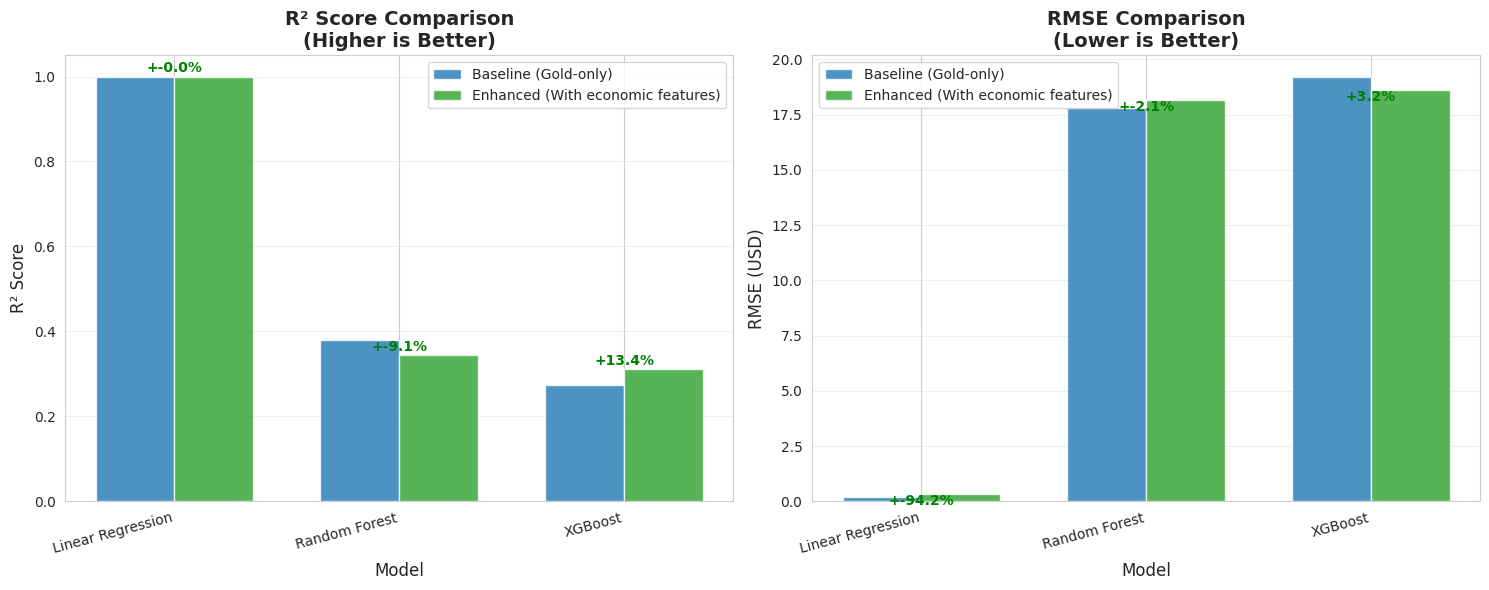

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models = comparison_combined['Model']
x_pos = np.arange(len(models))
width = 0.35

# R² Comparison
axes[0].bar(x_pos - width/2, comparison_combined['Baseline_R2'], width, 
            label='Baseline (Gold-only)', alpha=0.8, color='#1f77b4')
axes[0].bar(x_pos + width/2, comparison_combined['Enhanced_R2'], width,
            label='Enhanced (With economic features)', alpha=0.8, color='#2ca02c')

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
# axes[0].set_ylim([0.8, 1.0])

# Add improvement percentages
for i, (baseline, enhanced, improvement) in enumerate(zip(
    comparison_combined['Baseline_R2'],
    comparison_combined['Enhanced_R2'],
    comparison_combined['R2_Improvement_%']
)):
    axes[0].text(i, enhanced + 0.01, f'+{improvement:.1f}%', 
                ha='center', fontsize=10, fontweight='bold', color='green')

# RMSE Comparison
axes[1].bar(x_pos - width/2, comparison_combined['Baseline_RMSE'], width,
            label='Baseline (Gold-only)', alpha=0.8, color='#1f77b4')
axes[1].bar(x_pos + width/2, comparison_combined['Enhanced_RMSE'], width,
            label='Enhanced (With economic features)', alpha=0.8, color='#2ca02c')

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('RMSE (USD)', fontsize=12)
axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Add improvement percentages
for i, improvement in enumerate(comparison_combined['RMSE_Improvement_%']):
    y_pos = comparison_combined['Enhanced_RMSE'].values[i]
    axes[1].text(i, y_pos - 0.5, f'+{improvement:.1f}%',
                ha='center', fontsize=10, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('results/plots/baseline_vs_enhanced_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved baseline vs enhanced comparison")
plt.show()


Creating prediction plots for all models...
✓ Saved: all_models_predictions_enhanced.png


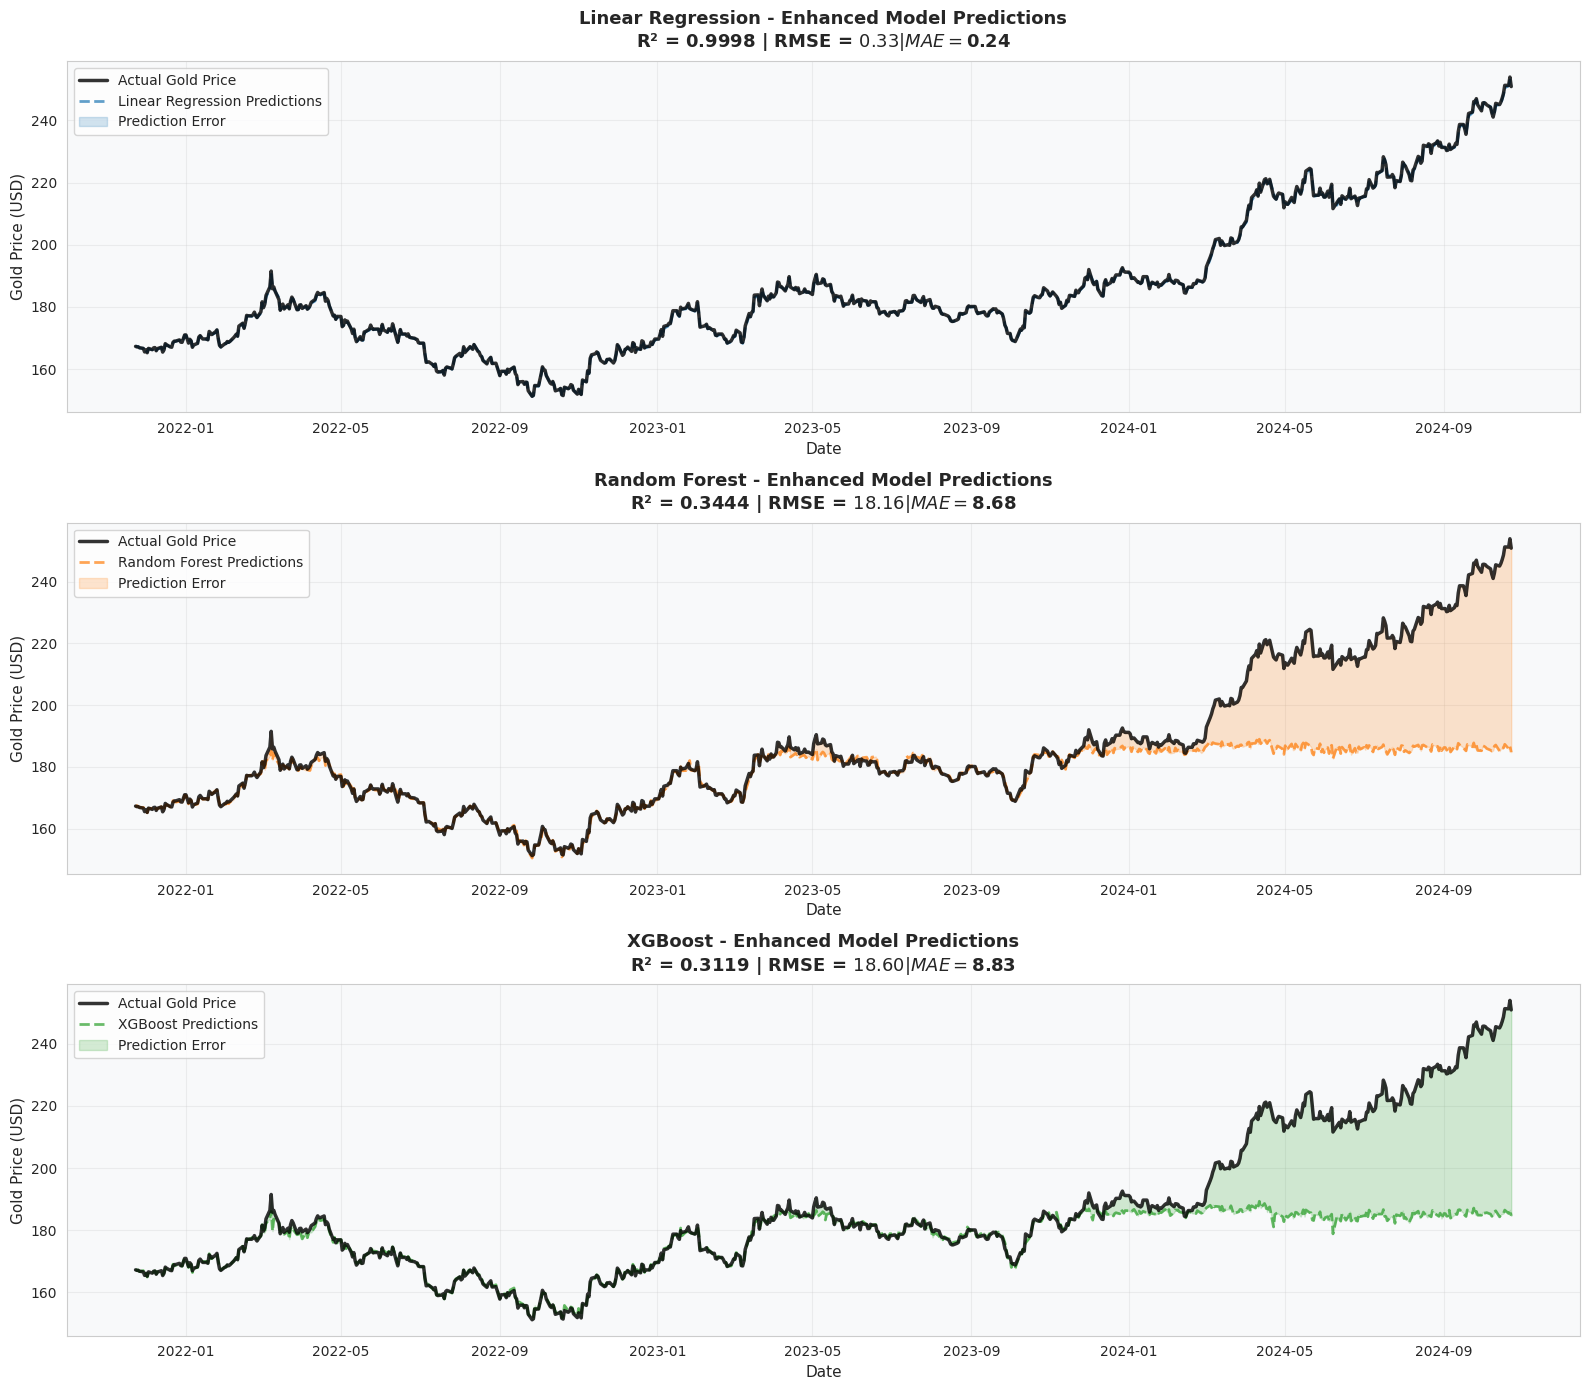

In [65]:
print("\n" + "="*60)
print("Creating prediction plots for all models...")
print("="*60)


# Create figure with 3 subplots (one per model)
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

models_data = [
    ('Linear Regression', y_pred_lr_enh_test, test_r2_lr_enh, test_rmse_lr_enh, "#1f77b4"),
    ('Random Forest', y_pred_rf_enh_test, test_r2_rf_enh, test_rmse_rf_enh, '#ff7f0e'),
    ('XGBoost', y_pred_xgb_enh_test, test_r2_xgb_enh, test_rmse_xgb_enh, '#2ca02c')
]

for idx, (model_name, predictions, r2, rmse, color) in enumerate(models_data):
    ax = axes[idx]
    
    # Plot actual prices (same for all)
    ax.plot(dates_test_enh.values, y_test_enh.values, 
            label='Actual Gold Price', 
            linewidth=2.5, 
            alpha=0.8, 
            color='black',
            zorder=2)
    
    # Plot predictions
    ax.plot(dates_test_enh.values, predictions,
            label=f'{model_name} Predictions',
            linewidth=2,
            alpha=0.7,
            color=color,
            linestyle='--',
            zorder=1)
    
    # Fill between to show error
    ax.fill_between(dates_test_enh.values,
                     y_test_enh.values,
                     predictions,
                     alpha=0.2,
                     color=color,
                     label='Prediction Error')
    
    # Title with metrics
    ax.set_title(f'{model_name} - Enhanced Model Predictions\n' + 
                f'R² = {r2:.4f} | RMSE = ${rmse:.2f} | MAE = ${mean_absolute_error(y_test_enh, predictions):.2f}',
                fontsize=13,
                fontweight='bold',
                pad=10)
    
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Gold Price (USD)', fontsize=11)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add subtle background color
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('results/plots/all_models_predictions_enhanced.png', dpi=300, bbox_inches='tight')
print("✓ Saved: all_models_predictions_enhanced.png")
plt.show()


Creating error analysis for all models...
✓ Saved: all_models_error_analysis.png


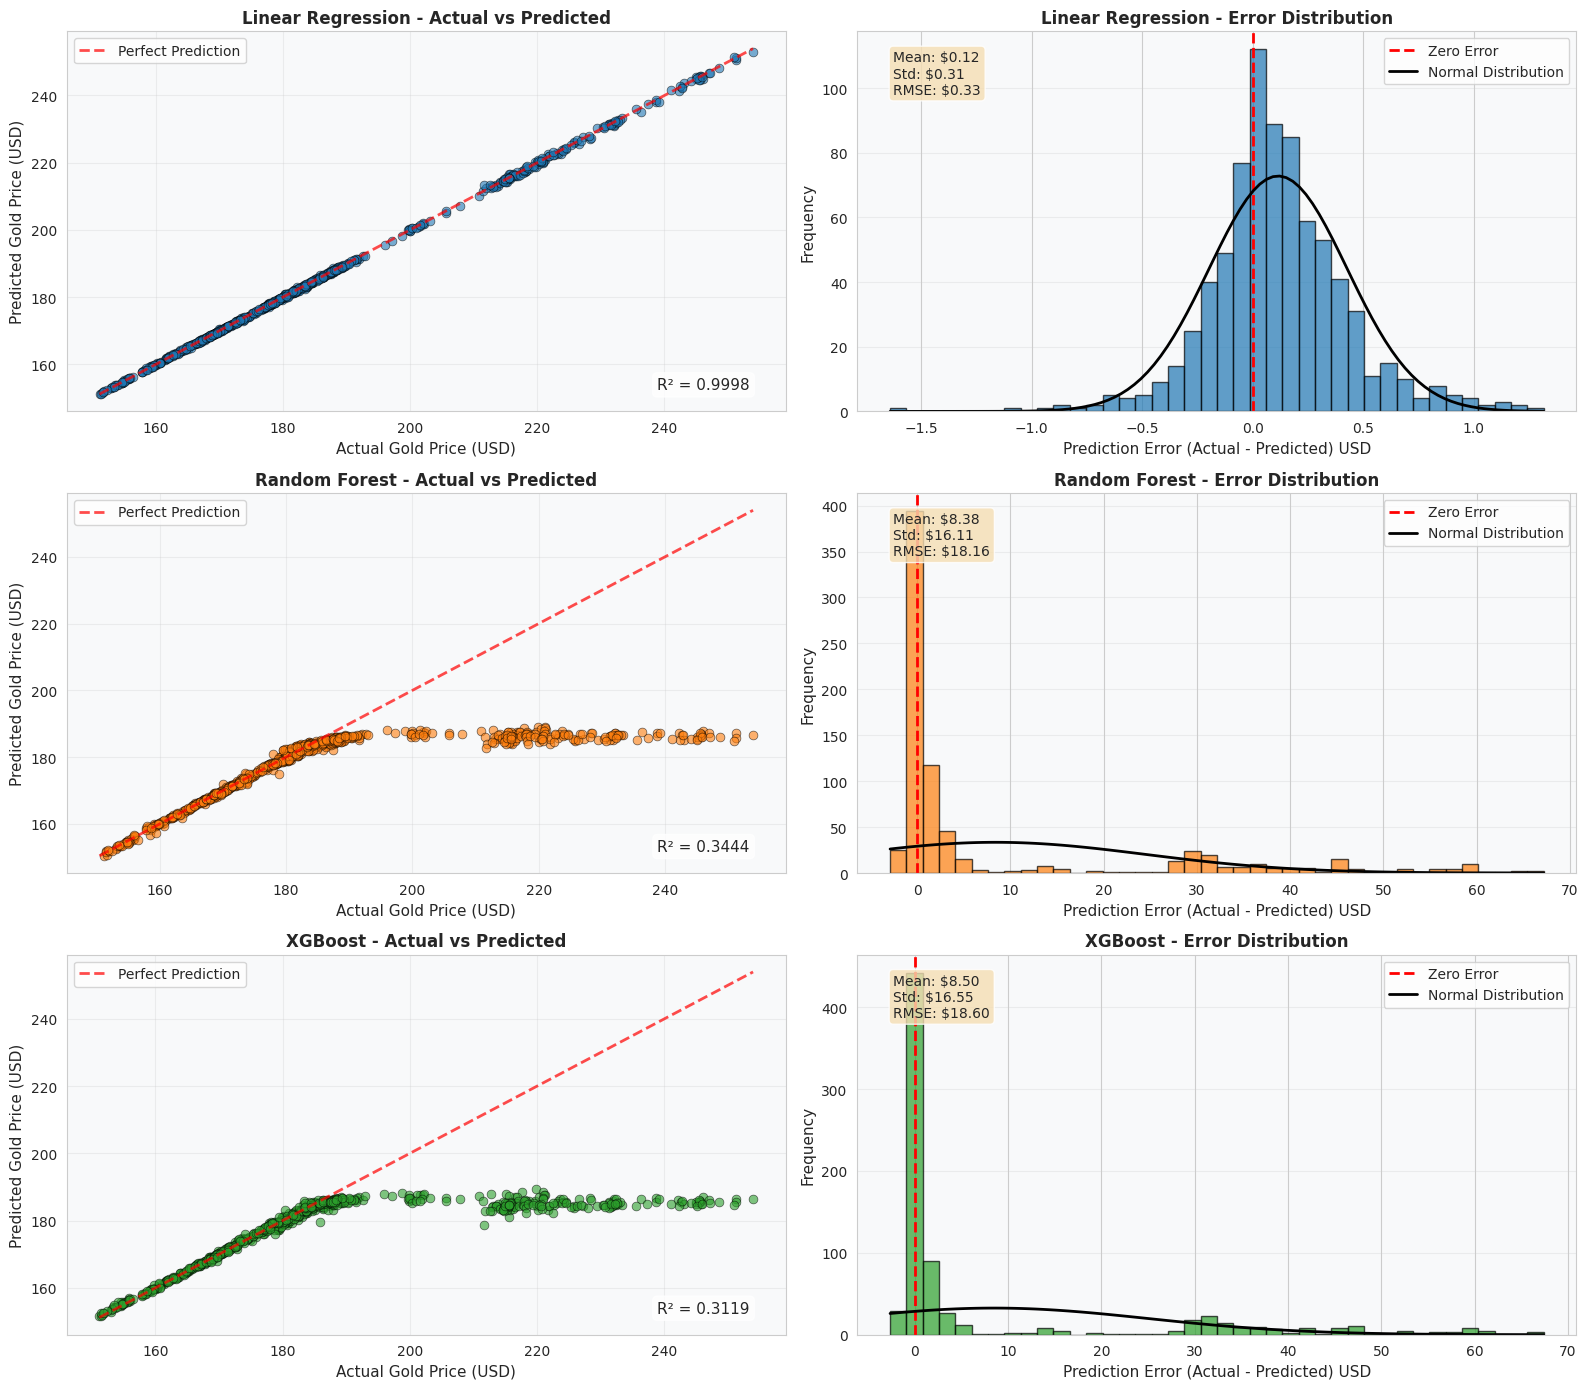

In [46]:
print("\nCreating error analysis for all models...")

# Create 3x2 grid: (predictions scatter, error distribution) for each model
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

models_data = [
    ('Linear Regression', y_pred_lr_enh_test, '#1f77b4'),
    ('Random Forest', y_pred_rf_enh_test, '#ff7f0e'),
    ('XGBoost', y_pred_xgb_enh_test, '#2ca02c')
]

for idx, (model_name, predictions, color) in enumerate(models_data):
    
    # Calculate errors
    errors = y_test_enh.values - predictions
    
    # LEFT COLUMN: Actual vs Predicted Scatter Plot
    ax_scatter = axes[idx, 0]
    
    # Perfect prediction line (45-degree)
    min_val = min(y_test_enh.min(), predictions.min())
    max_val = max(y_test_enh.max(), predictions.max())
    ax_scatter.plot([min_val, max_val], [min_val, max_val], 
                   'r--', linewidth=2, label='Perfect Prediction', alpha=0.7)
    
    # Scatter plot
    ax_scatter.scatter(y_test_enh.values, predictions, 
                      alpha=0.6, s=40, color=color, edgecolors='black', linewidth=0.5)
    
    ax_scatter.set_xlabel('Actual Gold Price (USD)', fontsize=11)
    ax_scatter.set_ylabel('Predicted Gold Price (USD)', fontsize=11)
    ax_scatter.set_title(f'{model_name} - Actual vs Predicted', 
                        fontsize=12, fontweight='bold')
    ax_scatter.legend(loc='upper left', fontsize=10)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_facecolor('#f8f9fa')
    
    # Add R² annotation
    ax_scatter.text(0.95, 0.05, f'R² = {r2_score(y_test_enh, predictions):.4f}',
                   transform=ax_scatter.transAxes,
                   fontsize=11,
                   verticalalignment='bottom',
                   horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # RIGHT COLUMN: Error Distribution
    ax_hist = axes[idx, 1]
    
    # Histogram
    n, bins, patches = ax_hist.hist(errors, bins=40, 
                                     edgecolor='black', 
                                     alpha=0.7, 
                                     color=color)
    
    # Add vertical line at 0
    ax_hist.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    
    # Add normal distribution overlay
    from scipy import stats
    mu = np.mean(errors)
    sigma = np.std(errors)
    x = np.linspace(errors.min(), errors.max(), 100)
    ax_hist.plot(x, stats.norm.pdf(x, mu, sigma) * len(errors) * (bins[1] - bins[0]),
                'k-', linewidth=2, label='Normal Distribution')
    
    ax_hist.set_xlabel('Prediction Error (Actual - Predicted) USD', fontsize=11)
    ax_hist.set_ylabel('Frequency', fontsize=11)
    ax_hist.set_title(f'{model_name} - Error Distribution', 
                     fontsize=12, fontweight='bold')
    ax_hist.legend(loc='upper right', fontsize=10)
    ax_hist.grid(True, alpha=0.3, axis='y')
    ax_hist.set_facecolor('#f8f9fa')
    
    # Add statistics box
    stats_text = f'Mean: ${mu:.2f}\nStd: ${sigma:.2f}\nRMSE: ${np.sqrt(mean_squared_error(y_test_enh, predictions)):.2f}'
    ax_hist.text(0.05, 0.95, stats_text,
                transform=ax_hist.transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('results/plots/all_models_error_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: all_models_error_analysis.png")
plt.show()


Creating residual plots for all models...
✓ Saved: all_models_residuals.png


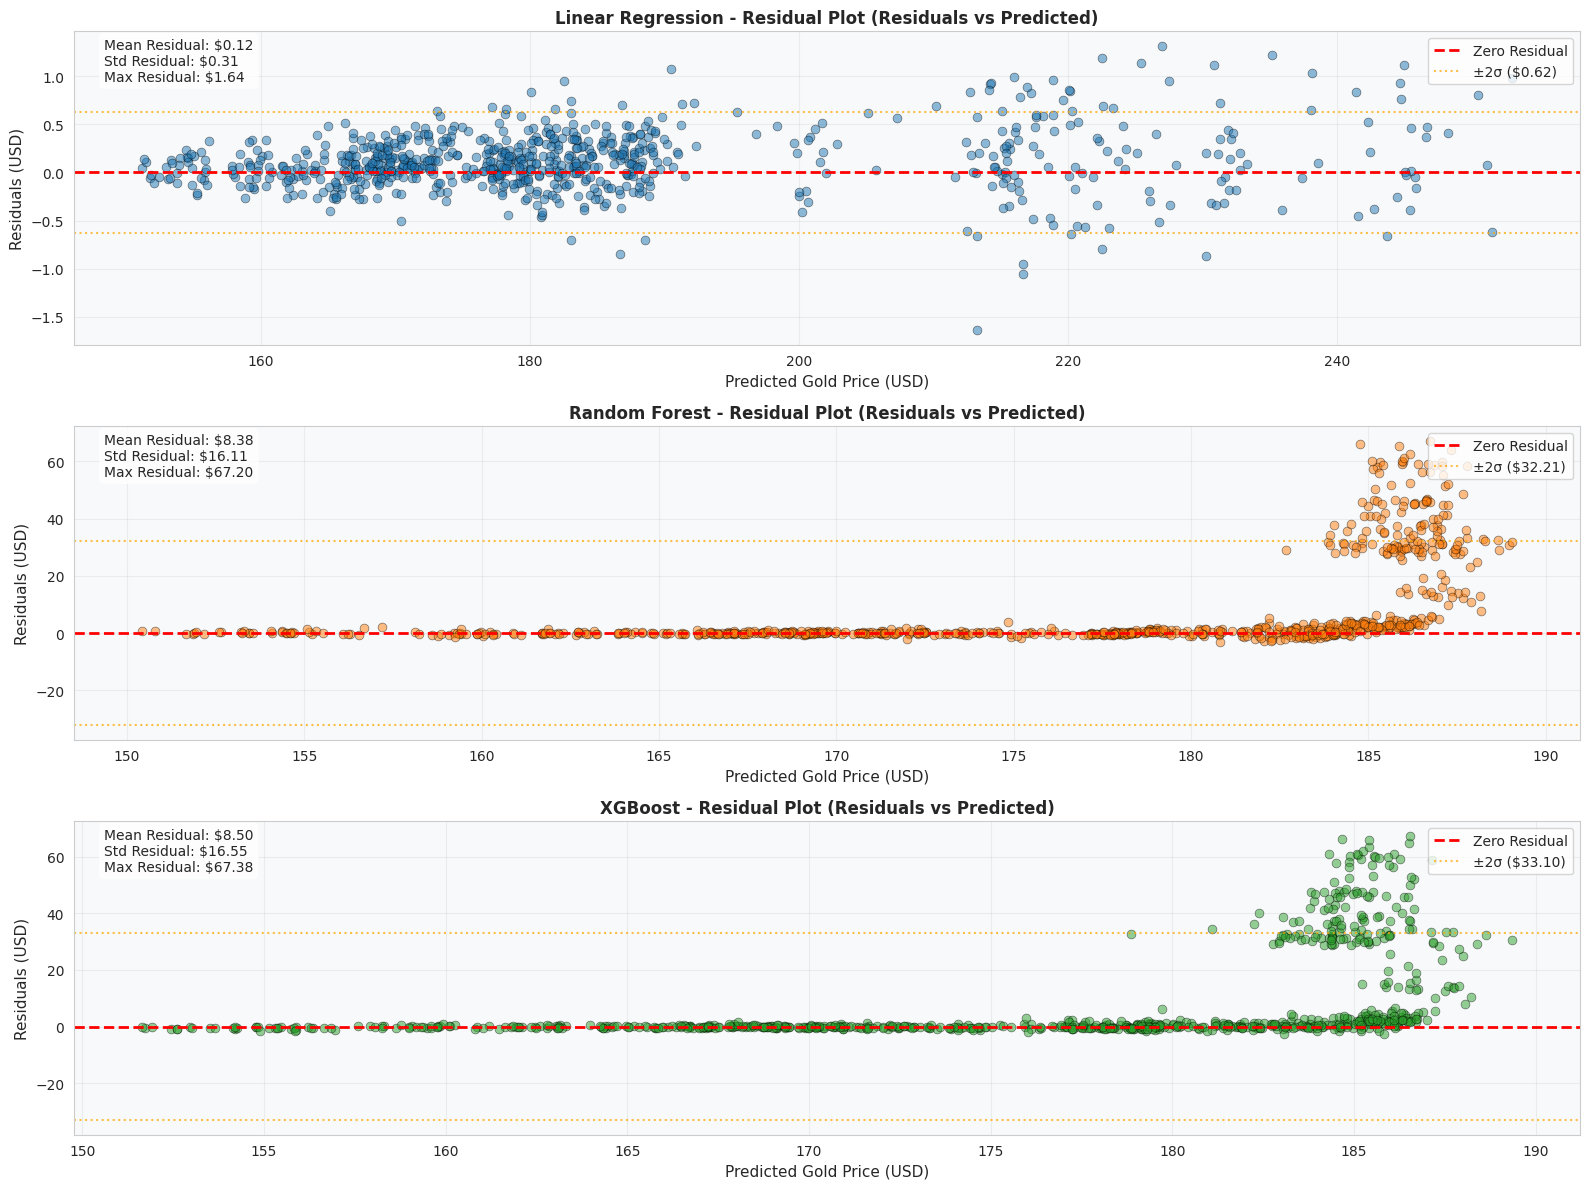

In [47]:
print("\nCreating residual plots for all models...")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

models_data = [
    ('Linear Regression', y_pred_lr_enh_test, '#1f77b4'),
    ('Random Forest', y_pred_rf_enh_test, '#ff7f0e'),
    ('XGBoost', y_pred_xgb_enh_test, '#2ca02c')
]

for idx, (model_name, predictions, color) in enumerate(models_data):
    ax = axes[idx]
    
    # Calculate residuals
    residuals = y_test_enh.values - predictions
    
    # Scatter plot of residuals vs predicted values
    ax.scatter(predictions, residuals, 
              alpha=0.5, s=40, color=color, edgecolors='black', linewidth=0.5)
    
    # Zero line
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
    
    # Add confidence bands (±2 sigma)
    sigma = np.std(residuals)
    ax.axhline(y=2*sigma, color='orange', linestyle=':', linewidth=1.5, 
              label=f'±2σ (${2*sigma:.2f})', alpha=0.7)
    ax.axhline(y=-2*sigma, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Predicted Gold Price (USD)', fontsize=11)
    ax.set_ylabel('Residuals (USD)', fontsize=11)
    ax.set_title(f'{model_name} - Residual Plot (Residuals vs Predicted)', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    
    # Add statistics
    mean_resid = np.mean(residuals)
    std_resid = np.std(residuals)
    
    stats_text = f'Mean Residual: ${mean_resid:.2f}\n'
    stats_text += f'Std Residual: ${std_resid:.2f}\n'
    stats_text += f'Max Residual: ${np.max(np.abs(residuals)):.2f}'
    
    ax.text(0.02, 0.98, stats_text,
           transform=ax.transAxes,
           fontsize=10,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('results/plots/all_models_residuals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: all_models_residuals.png")
plt.show()


Creating error evolution over time...
✓ Saved: all_models_error_evolution.png


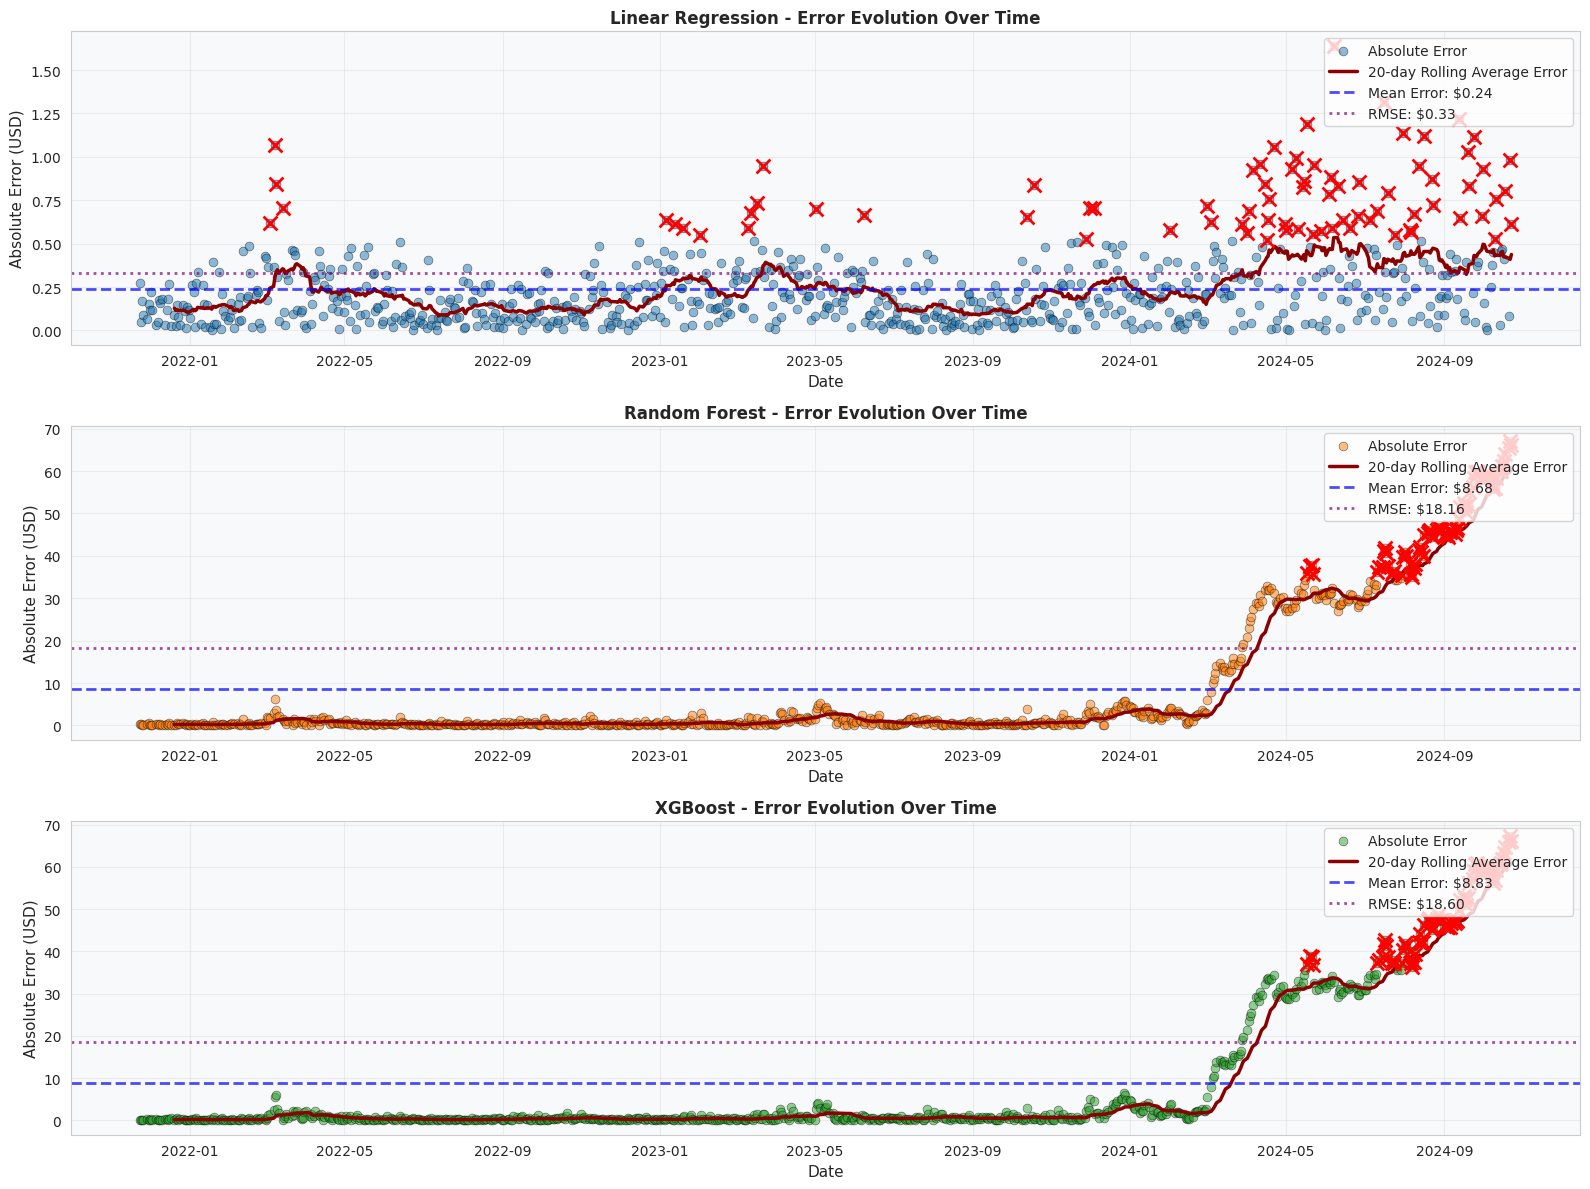

In [48]:
print("\nCreating error evolution over time...")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

models_data = [
    ('Linear Regression', y_pred_lr_enh_test, test_rmse_lr_enh, '#1f77b4'),
    ('Random Forest', y_pred_rf_enh_test, test_rmse_rf_enh, '#ff7f0e'),
    ('XGBoost', y_pred_xgb_enh_test, test_rmse_xgb_enh, '#2ca02c')
]

for idx, (model_name, predictions, rmse, color) in enumerate(models_data):
    ax = axes[idx]
    
    # Calculate absolute errors
    abs_errors = np.abs(y_test_enh.values - predictions)
    
    # Plot errors over time
    ax.scatter(dates_test_enh.values, abs_errors, 
              alpha=0.5, s=40, color=color, edgecolors='black', linewidth=0.5,
              label='Absolute Error')
    
    # Add rolling average of errors (20-day window)
    rolling_error = pd.Series(abs_errors).rolling(window=20).mean()
    ax.plot(dates_test_enh.values, rolling_error,
           color='darkred', linewidth=2.5, label='20-day Rolling Average Error')
    
    # Add mean error line
    ax.axhline(y=np.mean(abs_errors), color='blue', linestyle='--', 
              linewidth=2, label=f'Mean Error: ${np.mean(abs_errors):.2f}', alpha=0.7)
    
    # Add RMSE line
    ax.axhline(y=rmse, color='purple', linestyle=':', 
              linewidth=2, label=f'RMSE: ${rmse:.2f}', alpha=0.7)
    
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Absolute Error (USD)', fontsize=11)
    ax.set_title(f'{model_name} - Error Evolution Over Time', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    
    # Highlight periods of high error
    high_error_threshold = np.percentile(abs_errors, 90)
    high_error_mask = abs_errors > high_error_threshold
    
    if high_error_mask.sum() > 0:
        ax.scatter(dates_test_enh.values[high_error_mask], 
                  abs_errors[high_error_mask],
                  color='red', s=100, marker='x', linewidth=2,
                  label=f'High Errors (>90th percentile)', zorder=5)

plt.tight_layout()
plt.savefig('results/plots/all_models_error_evolution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: all_models_error_evolution.png")
plt.show()


Creating direct model comparison on same chart...
✓ Saved: all_models_direct_comparison.png


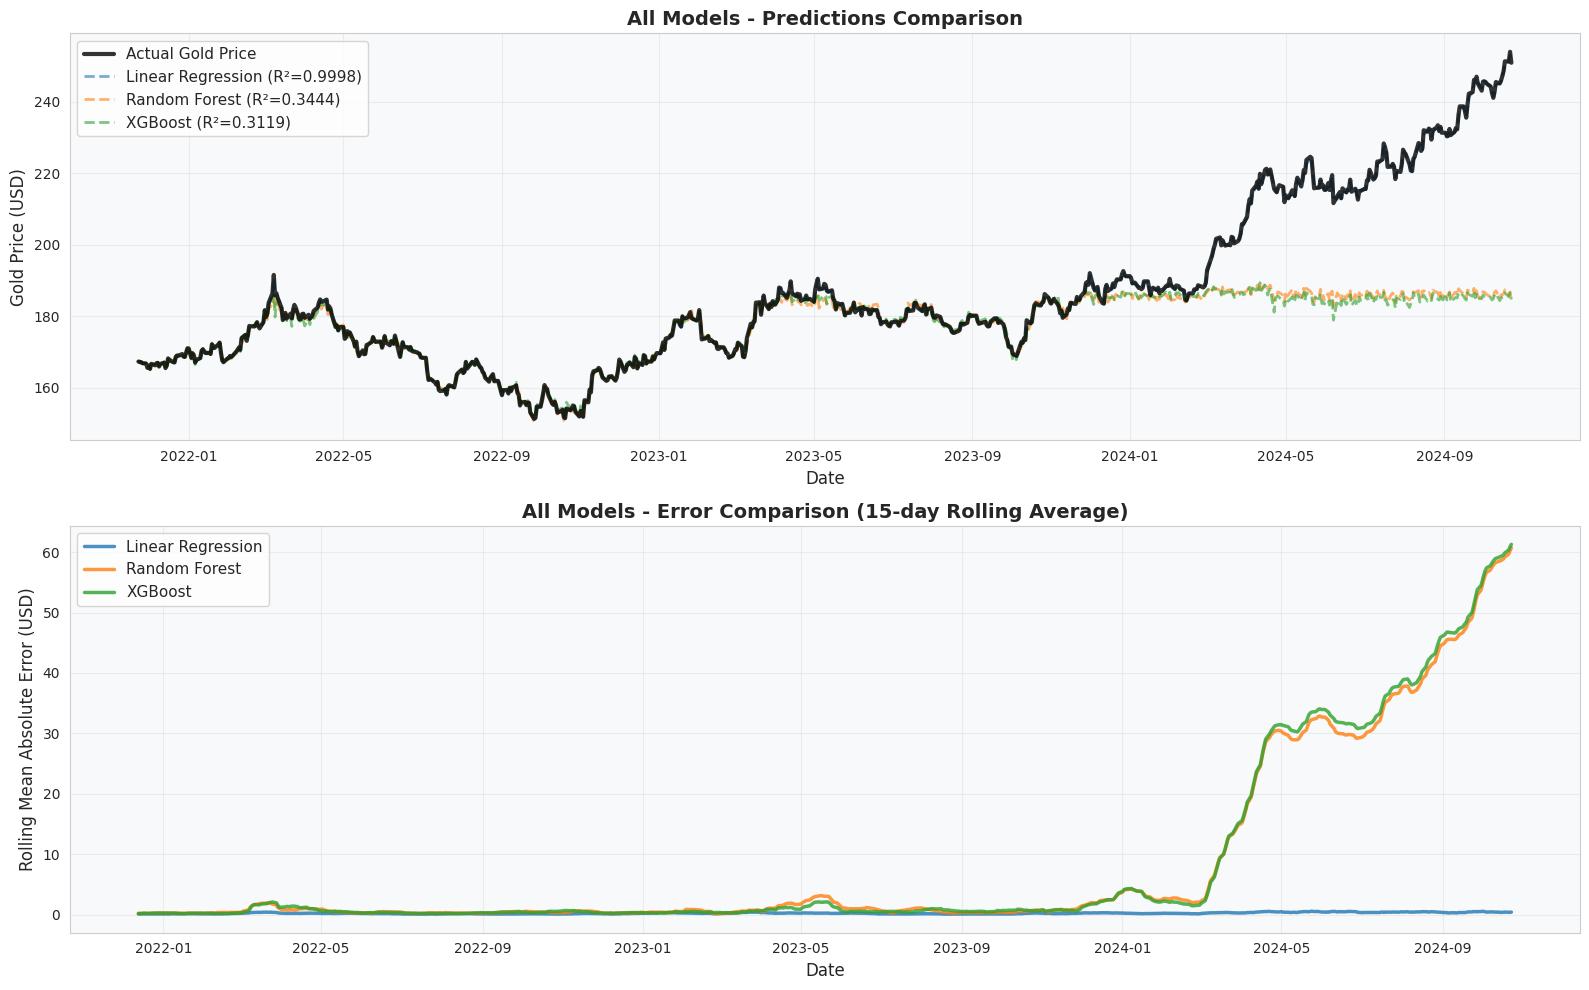

In [49]:
print("\nCreating direct model comparison on same chart...")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# TOP: All predictions vs actual on same plot
ax_pred = axes[0]

# Actual prices
ax_pred.plot(dates_test_enh.values, y_test_enh.values,
            label='Actual Gold Price',
            linewidth=3,
            color='black',
            alpha=0.8,
            zorder=4)

# All model predictions
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
models_info = [
    ('Linear Regression', y_pred_lr_enh_test, test_r2_lr_enh),
    ('Random Forest', y_pred_rf_enh_test, test_r2_rf_enh),
    ('XGBoost', y_pred_xgb_enh_test, test_r2_xgb_enh)
]

for (name, preds, r2), color in zip(models_info, colors):
    ax_pred.plot(dates_test_enh.values, preds,
                label=f'{name} (R²={r2:.4f})',
                linewidth=2,
                alpha=0.6,
                linestyle='--',
                color=color)

ax_pred.set_xlabel('Date', fontsize=12)
ax_pred.set_ylabel('Gold Price (USD)', fontsize=12)
ax_pred.set_title('All Models - Predictions Comparison', 
                 fontsize=14, fontweight='bold')
ax_pred.legend(loc='best', fontsize=11)
ax_pred.grid(True, alpha=0.3)
ax_pred.set_facecolor('#f8f9fa')

# BOTTOM: Absolute errors comparison
ax_err = axes[1]

for (name, preds, _), color in zip(models_info, colors):
    abs_errors = np.abs(y_test_enh.values - preds)
    rolling_error = pd.Series(abs_errors).rolling(window=15).mean()
    
    ax_err.plot(dates_test_enh.values, rolling_error,
               label=f'{name}',
               linewidth=2.5,
               alpha=0.8,
               color=color)

ax_err.set_xlabel('Date', fontsize=12)
ax_err.set_ylabel('Rolling Mean Absolute Error (USD)', fontsize=12)
ax_err.set_title('All Models - Error Comparison (15-day Rolling Average)', 
                fontsize=14, fontweight='bold')
ax_err.legend(loc='best', fontsize=11)
ax_err.grid(True, alpha=0.3)
ax_err.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('results/plots/all_models_direct_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: all_models_direct_comparison.png")
plt.show()


Creating performance metrics dashboard...


/tmp/ipykernel_6477/3424122379.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(error_data, labels=model_names, patch_artist=True,


✓ Saved: all_models_performance_dashboard.png


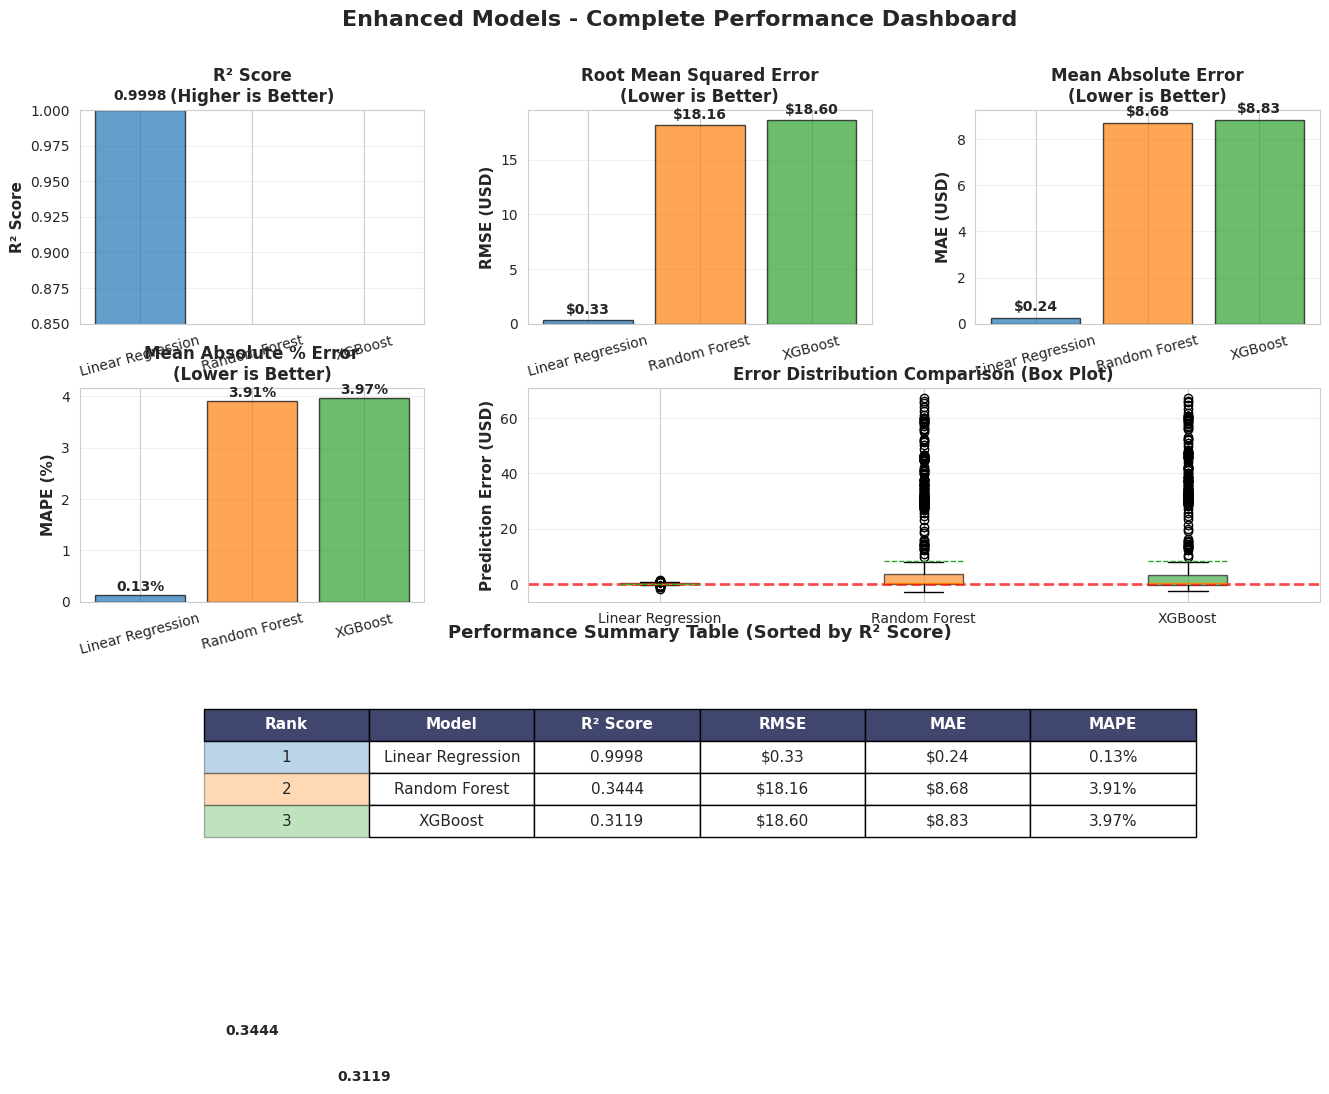

In [50]:
print("\nCreating performance metrics dashboard...")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

models_info = [
    ('Linear Regression', y_pred_lr_enh_test, test_r2_lr_enh, 
     test_rmse_lr_enh, test_mae_lr_enh, test_mape_lr_enh, '#1f77b4'),
    ('Random Forest', y_pred_rf_enh_test, test_r2_rf_enh, 
     test_rmse_rf_enh, test_mae_rf_enh, test_mape_rf_enh, '#ff7f0e'),
    ('XGBoost', y_pred_xgb_enh_test, test_r2_xgb_enh, 
     test_rmse_xgb_enh, test_mae_xgb_enh, test_mape_xgb_enh, '#2ca02c')
]

# Extract data for bar charts
model_names = [info[0] for info in models_info]
r2_scores = [info[2] for info in models_info]
rmse_scores = [info[3] for info in models_info]
mae_scores = [info[4] for info in models_info]
mape_scores = [info[5] for info in models_info]
colors = [info[6] for info in models_info]

# R² Score
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(model_names, r2_scores, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('R² Score\n(Higher is Better)', fontsize=12, fontweight='bold')
ax1.set_ylim([0.85, 1.0])
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=15)
# Add values on bars
for bar, val in zip(bars1, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSE
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(model_names, rmse_scores, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('RMSE (USD)', fontsize=11, fontweight='bold')
ax2.set_title('Root Mean Squared Error\n(Lower is Better)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, rmse_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'${val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# MAE
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(model_names, mae_scores, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('MAE (USD)', fontsize=11, fontweight='bold')
ax3.set_title('Mean Absolute Error\n(Lower is Better)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, mae_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'${val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# MAPE
ax4 = fig.add_subplot(gs[1, 0])
bars4 = ax4.bar(model_names, mape_scores, color=colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('MAPE (%)', fontsize=11, fontweight='bold')
ax4.set_title('Mean Absolute % Error\n(Lower is Better)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.tick_params(axis='x', rotation=15)
for bar, val in zip(bars4, mape_scores):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Error distribution comparison (box plot)
ax5 = fig.add_subplot(gs[1, 1:])
error_data = []
for name, preds, *_ in models_info:
    errors = y_test_enh.values - preds
    error_data.append(errors)

bp = ax5.boxplot(error_data, labels=model_names, patch_artist=True,
                 showmeans=True, meanline=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax5.set_ylabel('Prediction Error (USD)', fontsize=11, fontweight='bold')
ax5.set_title('Error Distribution Comparison (Box Plot)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Overall ranking table
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')

# Create ranking
ranking_data = []
for i, (name, _, r2, rmse, mae, mape, _) in enumerate(models_info, 1):
    ranking_data.append([i, name, f'{r2:.4f}', f'${rmse:.2f}', f'${mae:.2f}', f'{mape:.2f}%'])

table = ax6.table(cellText=ranking_data,
                 colLabels=['Rank', 'Model', 'R² Score', 'RMSE', 'MAE', 'MAPE'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0.1, 0.2, 0.8, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Color code the ranking
for i in range(len(ranking_data)):
    table[(i+1, 0)].set_facecolor(colors[i])
    table[(i+1, 0)].set_alpha(0.3)

# Header styling
for j in range(6):
    table[(0, j)].set_facecolor('#40466e')
    table[(0, j)].set_text_props(weight='bold', color='white')

ax6.set_title('Performance Summary Table (Sorted by R² Score)', 
             fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Enhanced Models - Complete Performance Dashboard', 
            fontsize=16, fontweight='bold', y=0.98)

plt.savefig('results/plots/all_models_performance_dashboard.png', dpi=300, bbox_inches='tight')
print("✓ Saved: all_models_performance_dashboard.png")
plt.show()

In [51]:
print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)

visualization_files = [
    "baseline_vs_enhanced_comparison.png - Bar charts comparing baseline vs enhanced",
    "all_models_predictions_enhanced.png - 3 subplots showing each model's predictions",
    "all_models_error_analysis.png - 3x2 grid: scatter + histogram for each model",
    "all_models_residuals.png - Residual plots for all 3 models",
    "all_models_error_evolution.png - Errors over time for all 3 models",
    "all_models_direct_comparison.png - All predictions on same chart",
    "all_models_performance_dashboard.png - Complete metrics dashboard",
    "enhanced_feature_importance.png - Top 20 important features (XGBoost)",
    "report_card_linear_regression.png - Individual report for Linear Regression",
    "report_card_random_forest.png - Individual report for Random Forest",
    "report_card_xgboost.png - Individual report for XGBoost"
]

print("\nFiles saved in results/plots/:")
for i, file in enumerate(visualization_files, 1):
    print(f"  {i}. {file}")

print("\n" + "="*80)
print(f"Total visualizations created: {len(visualization_files)}")
print("="*80)


VISUALIZATION SUMMARY

Files saved in results/plots/:
  1. baseline_vs_enhanced_comparison.png - Bar charts comparing baseline vs enhanced
  2. all_models_predictions_enhanced.png - 3 subplots showing each model's predictions
  3. all_models_error_analysis.png - 3x2 grid: scatter + histogram for each model
  4. all_models_residuals.png - Residual plots for all 3 models
  5. all_models_error_evolution.png - Errors over time for all 3 models
  6. all_models_direct_comparison.png - All predictions on same chart
  7. all_models_performance_dashboard.png - Complete metrics dashboard
  8. enhanced_feature_importance.png - Top 20 important features (XGBoost)
  9. report_card_linear_regression.png - Individual report for Linear Regression
  10. report_card_random_forest.png - Individual report for Random Forest
  11. report_card_xgboost.png - Individual report for XGBoost

Total visualizations created: 11
